In [1]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>Monk dataset NN</h1>
<p>Exploring monk dataset with neural network.</p>
<hr/>

In [2]:
import numpy as np
import optuna
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import tqdm as notebook_tqdm
from torch.nn import BCEWithLogitsLoss

import monk_common as mc
import nn_common as nnc
import cross_common as cr
import torch
from torch import nn
import importlib
from functools import partial
import copy
from nn_common import FeatureTargetSet, HoldOutStrategy, EarlyStoppingStrategy
from cross_common import EPOCHS_VL_MEE,FOLD_VL_MEE,FOLD_TR_MEE
from cross_common import MEE,MSE,RMSE,MAE

importlib.reload(nnc)
importlib.reload(mc)
importlib.reload(cr)

/Users/leonardo/workspace/library/source/it.unipi.654AA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<module 'cross_common' from '/Users/leonardo/workspace/library/source/it.unipi.654AA/notebooks/cross_common.py'>

<h3>Preparation</h3>
<hr/>

<h4>Hyperparameters and settings</h4>
<p>Default setting and hyper parameters for the NN run
</p>

<h4>Data preparation</h4>
<p>The train and test dataset are loaded in form of Pandas DataFrame for better interchangeability with PyTorch.
<ul>
<li>X_tr, y_tr: the train features and train labels (or classes)</li>
<li>X_ts, y_ts: the test features and test labels (or classes)</li>
</ul>
</p>

In [3]:
monk_data_set_id = 1
df_train, df_test = mc.load_set(monk_data_set_id)
X_tr, y_tr = mc.split_and_prepare_dataset(df_train)
X_ts, y_ts = mc.split_and_prepare_dataset(df_test)
mc.dataset_introspection(df_train, df_test)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>NN Architecture</h4>
<p>Defining the neural network architecture:
<ul>
<li><b>net</b>: represent the internal NN structure with input, hidden and output layer.
One important thing to consider is that the output layer <u>must be kept linear</u> in order to be able to
plug the loss function and the output adapter</li>
<li><b>output_adapter</b>: the function which takes the output from the NN and apply the latest trasformation (classification, regression, etc...).
Must be coherent with the optimizer_template. See function docs for details</li>
<li><b>model_template</b>: the model itself, a skeleton which holds the net structure, and the output adapter function.
The model is always cloned troughout the notebok, just to keep a template reference.</li>
<li><b>optimizer_template</b>: the weight update algorithm</li>
<li><b>scheduler_template</b>: implements adaptive learning rate decay by using ReduceLROnPlateau together with the optimizer template</li>
</ul>
</p>

In [4]:
# Optuna derived configuration
optuna_learning_rate = 0.003696275139658213 #0.00042823778171075926
optuna_weight_decay = 2.1597950273503433e-06 #0.00017587860733682737

optuna_batch_size = 20
optuna_epochs=500
optuna_hidden_layers = [16]
optuna_loss_function = BCEWithLogitsLoss()

default_seed = 1
default_min_delta = 0.001
torch.manual_seed(default_seed)

# Custom Hyperparameters
default_momentum = 0.5
default_nesterov = True

# The input dimension (i.e. the input layer) is obviously
# the number of feature of the TR set
input_dimension = X_tr.shape[1]
output_dimension = 1

# ----- Defining model architecture --------
hidden_layers = optuna_hidden_layers
net = nnc.build_nn_net(input_dimension, output_dimension, hidden_layers, "relu")

# The output and loss function, must be changed according to the type of task
loss_function = optuna_loss_function
output_adapter = nnc.binary_bce_adapter(threshold=0.5)

# Model implementation
#model_template = nnc.MLP(net, output_adapter)
# weights initialization (for academic purposes only)
#model_template.apply(lambda m: nnc.init_weights(m, method="kaiming", nonlinearity="relu"))
model_template = nnc.build_nn_model(net, output_adapter)
# ------------------------------------------


# ---- The metrics to calculate in train ---
# epochs_metrics_dict = {
#     #MEE: (cr.mee,min),MSE: (cr.mse,min),MAE: (cr.mae,min),
#     #RMSE: (cr.rmse,min),
#     #"custom": (loss_function,max)
#     "custom": (nnc.compute_bce_from_numpy,max)
# }
# ------------------------------------------


# -------The weight update algorithms ------
# optimizer_template = partial(
#     torch.optim.Adam,
#     lr = default_learning_rate,
#     weight_decay = 1e-4
# )

# optimizer_template = partial(
#     torch.optim.SGD,
#     lr = 0.01, #default_learning_rate,
#     #momentum = default_momentum,
#     #nesterov = default_nesterov,
#     weight_decay = default_weight_decay,
# )

optimizer_template = partial(
    torch.optim.AdamW,
    lr=optuna_learning_rate,
    weight_decay=optuna_weight_decay,
    betas=(0.95, 0.999)
)
# ------------------------------------------


# ---------- Learning rate decay -----------
# The factor by learning rate will decrease
learning_rate_decay_factor = 0.5    #0.6 #0.5
# The epoch to wait before applying the rate decay factor
learning_rate_decay_patience = 50
# The threshold for measuring the new optimum
learning_rate_decay_threshold = 1e-4

# The learning rate decay function
scheduler_template = partial(
    torch.optim.lr_scheduler.ReduceLROnPlateau,
    mode="min", factor=learning_rate_decay_factor, patience=learning_rate_decay_patience,
    threshold=learning_rate_decay_threshold
)
# ------------------------------------------


# --------- Early Stopping Strategy --------
early_stopping_patience = 50 # how many epochs to wait before stopping
early_stopping_min_delta = 1e-3 #1e-4 # the treshold or delta to declare an epochs as not improved
early_stopping_strategy = nnc.EarlyStoppingStrategy(patience=early_stopping_patience, min_delta=early_stopping_min_delta)
# ------------------------------------------

<h3>NN Run</h3>
<hr/>

<h4>KFold</h4>
<p>Perform training and validation according to KFold strategy.</p>

<h5>Training</h5>
<p>The number of epoch has been increased in respect to hold-out validation, but early stopping have also been enabled to avoid overfitting.</p>
<p>The StratifiedKFold has been choosed for this particular small dataset as it keeps a balance between classes.</p>

In [5]:
importlib.reload(nnc)
importlib.reload(cr)

kf = cr.common_fold_strategy(stratified=True)

inner_train_params = {
    "epochs": optuna_epochs,
    "batch_size": optuna_batch_size,
    "optimizer_template": optimizer_template,
    #"scheduler_template": scheduler_template,
    "loss_function": loss_function,
    "early_stopping_strategy": early_stopping_strategy,
}

fold_histories = nnc.kfold(
    model_template, X_tr, y_tr, kf, inner_train_params
)


  
Perform fold: 0, train size: 99, val size: 25
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 99
Validation      | samples: 25
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.003696275139658213, 'weight_decay': 2.1597950273503433e-06, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | metric: real,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
  
Perform fold: 1, train size: 99, val size: 25
Early stopping at epoch 439 (best VL real loss: 0.0031)
Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 500
Train           | samples: 99
Validation      | samples: 25
Batch type      | min

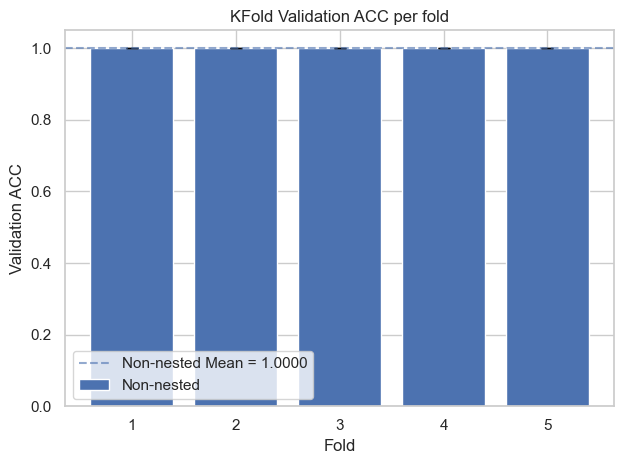

,TR,VL,Gap(TR-VL),Rel Gap(TR-VL)%
Fold,,,,
1,1.0,1.0,0.0,0.00%
2,1.0,1.0,0.0,0.00%
3,1.0,1.0,0.0,0.00%
4,1.0,1.0,0.0,0.00%
5,1.0,1.0,0.0,0.00%
MEAN,1.0,1.0,0.0,0.00%
STD,0.0,0.0,0.0,0.00%


In [6]:
for metric in ["acc"]:
    cr.plot_kfold_metric([(fold_histories,"Non-nested")], metric)
    display(cr.kfold_regression_table(fold_histories, use=metric))

<h5>Prediction</h5>
<p>Model is eventually trained with best parameters verified from KFold, in order to predict on official test set.</p>

In [7]:
importlib.reload(nnc)
model_kf = copy.deepcopy(model_template)

# Incrementing   epoch size with early stopping
inner_train_params_final = copy.deepcopy(inner_train_params)
inner_train_params_final["epochs"] = 1000


train_kf_result = nnc.train(
    model_kf, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr)),
    **inner_train_params_final
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 100
Validation      | samples: 24
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.003696275139658213, 'weight_decay': 2.1597950273503433e-06, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | metric: real,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------


In [20]:
epochs_kf_tr_acc = train_kf_result.epochs_tr_acc
epochs_kf_vl_acc = train_kf_result.epochs_vl_acc
epochs_kf_tr_real = train_kf_result.epochs_tr_real
epochs_kf_vl_real = train_kf_result.epochs_vl_real
epochs_kf_grad = train_kf_result.epochs_grad_norm

<p>The gradient norm should gradually decrease throughout epochs, indicating that the optimization process moves toward a stable region of the loss landscape.</p>

In [19]:
print(inner_train_params)
print(inner_train_params_final)

{'epochs': 500, 'batch_size': 20, 'optimizer_template': functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.003696275139658213, weight_decay=2.1597950273503433e-06, betas=(0.95, 0.999)), 'loss_function': BCEWithLogitsLoss(), 'early_stopping_strategy': <nn_common.EarlyStoppingStrategy object at 0x11e4aa510>}
{'epochs': 1000, 'batch_size': 20, 'optimizer_template': functools.partial(<class 'torch.optim.adamw.AdamW'>, lr=0.003696275139658213, weight_decay=2.1597950273503433e-06, betas=(0.95, 0.999)), 'loss_function': BCEWithLogitsLoss(), 'early_stopping_strategy': <nn_common.EarlyStoppingStrategy object at 0x124db4b90>}


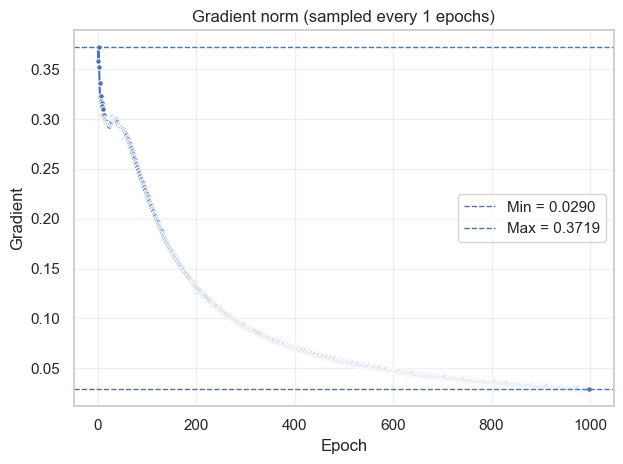

In [9]:
importlib.reload(nnc)
nnc.plot_gradient_norm_line(epochs_kf_grad, step=1)

<Figure size 640x480 with 0 Axes>

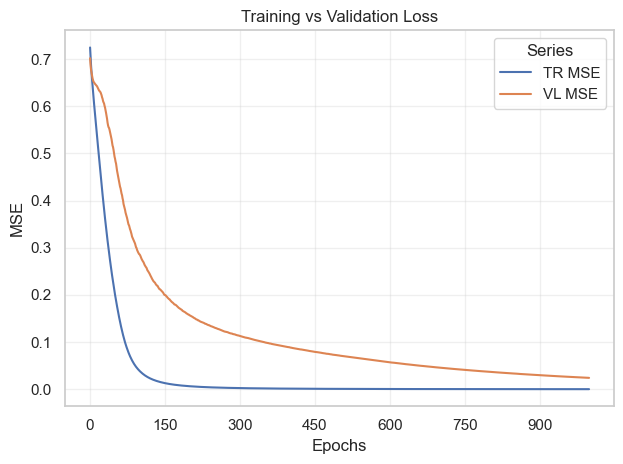

In [10]:
nnc.plot_epoch_mse(epochs_kf_tr_real, epochs_kf_vl_real)

<Figure size 640x480 with 0 Axes>

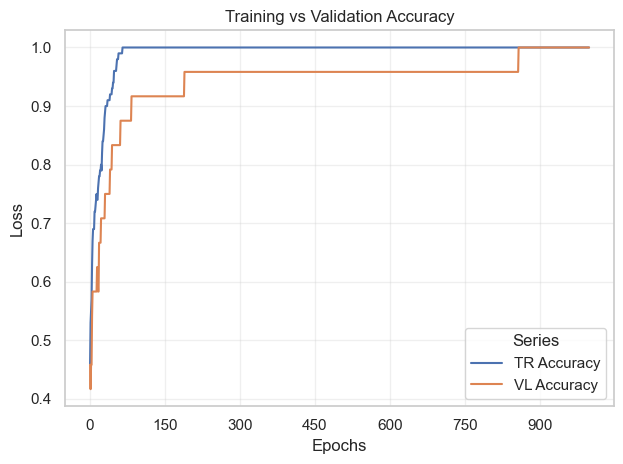

In [11]:
importlib.reload(nnc)
nnc.plot_epoch_accuracy(epochs_kf_tr_acc, epochs_kf_vl_acc)

In [12]:
importlib.reload(nnc)
y_kf_pred = mc.classification_helper(model_kf.predict(X_ts)) #pd.DataFrame(all_pred[0].detach().cpu().numpy())
print(classification_report(y_ts, y_kf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       216
           1       1.00      0.99      0.99       216

    accuracy                           0.99       432
   macro avg       0.99      0.99      0.99       432
weighted avg       0.99      0.99      0.99       432



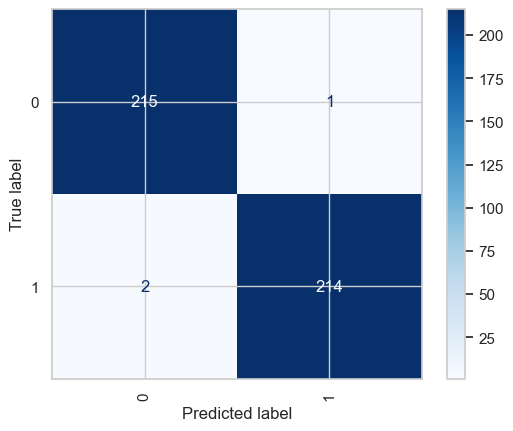

In [13]:
ConfusionMatrixDisplay.from_predictions(y_ts, y_kf_pred, xticks_rotation='vertical', cmap='Blues');

<hr/>

Generated Set

In [14]:
importlib.reload(mc)
df_g = mc.generate_monk_set(monk_data_set_id, 2000, 0.2)
X_g, y_g = mc.split_and_prepare_dataset(df_g)


In [15]:
y_g_pred = model_kf.predict(X_g)

In [16]:
y_g_pred_2 = mc.classification_helper(y_g_pred)
print(classification_report(y_g, y_g_pred_2))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80      1012
           1       0.80      0.80      0.80       988

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



In [17]:
model_kf = copy.deepcopy(model_template)

# Incrementing   epoch size with early stopping
inner_train_params_final = copy.deepcopy(inner_train_params)
inner_train_params_final["epochs"] = 1000


train_kf_result = nnc.train(
    model_kf, nnc.HoldOutStrategy(nnc.FeatureTargetSet(X_tr, y_tr)),
    **inner_train_params_final
)

Train summary
----------------------------------------------------------------------------------------------------
Epochs          | 1000
Train           | samples: 100
Validation      | samples: 24
Batch type      | mini-batch (20)
Loss function   | BCEWithLogitsLoss()
Optimizer       | class: <class 'torch.optim.adamw.AdamW'> , params: {'lr': 0.003696275139658213, 'weight_decay': 2.1597950273503433e-06, 'betas': (0.95, 0.999)}
LR Decay        | disabled
Early Stopping  | metric: real,  patience: 50 , minimum delta: 0.001
----------------------------------------------------------------------------------------------------
